# 02 — EDA y visualizaciones: películas vs series
**Curso:** ADY1104 · **Evaluación:** EP3 · **Caso:** StreamView Analytics

**Pregunta de negocio:** ¿cómo debería StreamView repartir su inversión en adquisición entre películas y series, y en qué géneros/países?

**Audiencia (todos los gráficos):** Gerencia de Contenido y Dirección Ejecutiva.

**Reglas:** una métrica = un criterio (orden = largo = título) · porcentajes sobre base fija · Película = azul, Serie = naranja · gris para lo no destacado.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt

ROOT = Path.cwd().parent                      # el notebook vive en notebooks/
PROC, IMG = ROOT / "data" / "processed", ROOT / "images"
IMG.mkdir(exist_ok=True)

TIPOS = ["Película", "Serie"]
COLOR = {"Película": "#0072B2", "Serie": "#E69F00"}   # Okabe-Ito: aptos para daltonismo
GRIS, TEXTO = "#BDBDBD", "#222222"
mpl.rcParams.update({"font.size": 10, "axes.edgecolor": "#888888", "text.color": TEXTO,
                     "axes.labelcolor": TEXTO, "xtick.color": TEXTO, "ytick.color": TEXTO,
                     "axes.spines.top": False, "axes.spines.right": False, "axes.grid": False})

df = pd.read_csv(PROC / "contenido_unificado.csv")
gen = pd.read_csv(PROC / "contenido_por_genero.csv")
pais = pd.read_csv(PROC / "contenido_por_pais.csv")
direc = pd.read_csv(PROC / "contenido_por_director.csv")
NO_ESP = "No especificado"
N_TIPO = df.groupby("tipo_contenido").size()          # BASE FIJA para todos los porcentajes
CIFRAS = []                                           # cifras clave por gráfico (control cruzado)

def encabezado(fig, mensaje, subtitulo):
    fig.suptitle(mensaje, x=0.01, y=1.04, ha="left", fontsize=13, fontweight="bold")
    fig.text(0.01, 0.985, subtitulo, ha="left", va="top", fontsize=9, color="#555555")

def guardar(fig, nombre):
    fig.savefig(IMG / nombre, dpi=200, bbox_inches="tight", facecolor="white")
    plt.show()

def cifra(grafico, nombre, valor):
    CIFRAS.append({"grafico": grafico, "cifra": nombre, "valor": round(float(valor), 3)})

## G1 — Calidad y cobertura de votos
- **Problema:** ¿qué tipo de contenido se percibe mejor, y cuánto podemos confiar en esa nota?
- **Mensaje:** las series puntúan más alto, pero pocas tienen votos suficientes.
- **Métrica:** calificación promedio (solo con votos) y % con ≥ 10 votos (base: total del tipo).
- **Por qué barras:** dos valores por tipo; la longitud desde cero se compara sin esfuerzo.

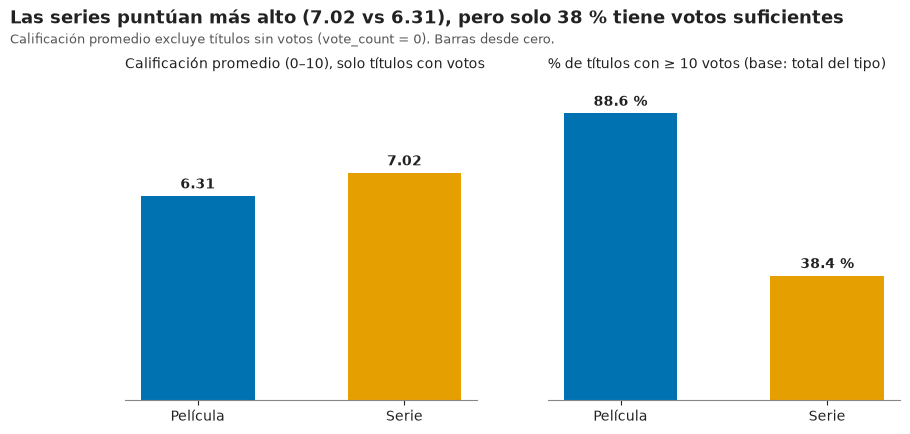

In [2]:
q = df.groupby("tipo_contenido").agg(calif=("vote_average_clean", "mean"),
                                     conf=("calificacion_confiable", "mean"))
q["conf"] *= 100
fig, ax = plt.subplots(1, 2, figsize=(10, 4.2))
for a, col, fmt, lim, ttl in [
        (ax[0], "calif", "{:.2f}", 10, "Calificación promedio (0–10), solo títulos con votos"),
        (ax[1], "conf", "{:.1f} %", 100, "% de títulos con ≥ 10 votos (base: total del tipo)")]:
    vals = q.loc[TIPOS, col]
    b = a.bar(TIPOS, vals, color=[COLOR[t] for t in TIPOS], width=0.55)
    a.bar_label(b, labels=[fmt.format(v) for v in vals], padding=3, fontweight="bold")
    a.set_ylim(0, lim); a.set_yticks([]); a.spines["left"].set_visible(False)
    a.set_title(ttl, loc="left", fontsize=10)
mas = "más" if q.loc["Serie", "calif"] > q.loc["Película", "calif"] else "menos"
encabezado(fig, f"Las series puntúan {mas} alto ({q.loc['Serie','calif']:.2f} vs {q.loc['Película','calif']:.2f}), "
                f"pero solo {q.loc['Serie','conf']:.0f} % tiene votos suficientes",
           "Calificación promedio excluye títulos sin votos (vote_count = 0). Barras desde cero.")
guardar(fig, "g1_calidad_y_cobertura.png")
for t in TIPOS:
    cifra("G1", f"calificacion_prom_{t}", q.loc[t, "calif"]); cifra("G1", f"pct_confiable_{t}", q.loc[t, "conf"])

## G2 — Popularidad sesgada: la mediana es más representativa que el promedio
- **Problema:** ¿el promedio de popularidad representa a un título típico?
- **Mensaje:** la distribución es muy sesgada; hay que reportar la mediana.
- **Métrica:** `popularity` original, dentro de cada tipo (escalas no comparables entre tipos).
- **Por qué boxplot:** resume mediana, dispersión y atípicos; los atípicos (> Q3 + 1,5·IQR) se excluyen del dibujo y se cuantifican.

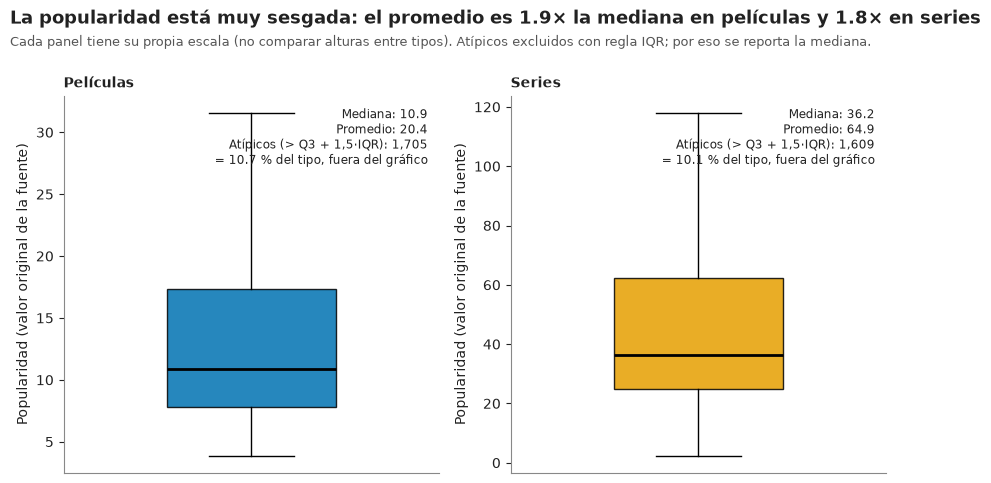

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(9, 4.6))
ratios = {}
for ax_, t in zip(axes, TIPOS):
    x = df.loc[df.tipo_contenido == t, "popularity"]
    q1, q3 = x.quantile([0.25, 0.75]); valla = q3 + 1.5 * (q3 - q1)
    n_out = int((x > valla).sum()); ratios[t] = x.mean() / x.median()
    ax_.boxplot(x, showfliers=False, whis=1.5, patch_artist=True, widths=0.45,
                boxprops=dict(facecolor=COLOR[t], alpha=0.85),
                medianprops=dict(color="black", linewidth=2))
    ax_.set_xticks([]); ax_.set_title(t + "s", loc="left", fontsize=10, fontweight="bold")
    ax_.set_ylabel("Popularidad (valor original de la fuente)")
    ax_.text(0.97, 0.97, f"Mediana: {x.median():.1f}\nPromedio: {x.mean():.1f}\n"
             f"Atípicos (> Q3 + 1,5·IQR): {n_out:,}\n= {n_out/len(x)*100:.1f} % del tipo, fuera del gráfico",
             transform=ax_.transAxes, ha="right", va="top", fontsize=8.5)
    cifra("G2", f"mediana_popularidad_{t}", x.median()); cifra("G2", f"atipicos_{t}", n_out)
encabezado(fig, f"La popularidad está muy sesgada: el promedio es {ratios['Película']:.1f}× la mediana en películas "
                f"y {ratios['Serie']:.1f}× en series",
           "Cada panel tiene su propia escala (no comparar alturas entre tipos). Atípicos excluidos con regla IQR; "
           "por eso se reporta la mediana.")
fig.tight_layout(); guardar(fig, "g2_popularidad_boxplot_iqr.png")

## G3 — Engagement y calidad por género: los géneros más vistos no siempre son los mejor calificados
- **Problema:** ¿qué géneros combinan alto engagement y buena calificación?
- **Mensaje:** el título del gráfico indica qué género lidera cada métrica en cada tipo (se calcula desde los datos).
- **Métrica:** eje X = índice de engagement mediano (percentil dentro del tipo; la mediana evita el sesgo de G2); eje Y = calificación promedio solo con ≥ 10 votos; tamaño = cantidad de títulos.
- **Por qué dispersión:** dos métricas continuas por género; la posición es el atributo más fácil de leer. Líneas punteadas = valor típico del tipo.

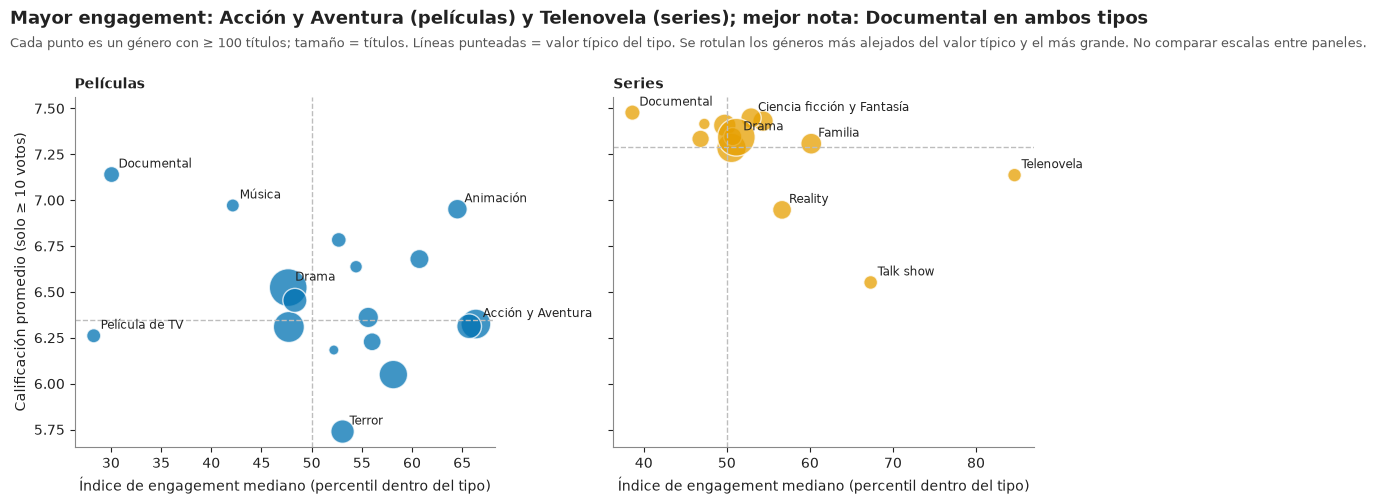

In [4]:
g = gen[gen.genero_unificado != NO_ESP]                       # también lo usa G4
base = g.assign(nota=g.vote_average_clean.where(g.calificacion_confiable))   # solo notas con ≥ 10 votos
d = (base.groupby(["tipo_contenido", "genero_unificado"])
         .agg(n=("content_id", "size"), eng=("indice_engagement", "median"),
              calif=("nota", "mean"), n_conf=("nota", "count"))
         .reset_index())
d = d[(d.n >= 100) & (d.n_conf >= 30)]

fig, axes = plt.subplots(1, 2, figsize=(11, 4.8), sharey=True)
lider = {}
for ax_, t in zip(axes, TIPOS):
    s = d[d.tipo_contenido == t]
    lider[t] = (s.loc[s.eng.idxmax(), "genero_unificado"], s.loc[s.calif.idxmax(), "genero_unificado"])
    ax_.scatter(s.eng, s.calif, s=s.n / s.n.max() * 700 + 40, color=COLOR[t], alpha=0.75, edgecolor="white")
    # rotular solo los 6 géneros más alejados del valor típico y el más grande (evita que se pisen las etiquetas)
    dist = ((s.eng - 50) / s.eng.std()) ** 2 + ((s.calif - s.calif.mean()) / s.calif.std()) ** 2
    rotular = set(s.loc[dist.nlargest(6).index, "genero_unificado"]) | set(s.loc[s.n.idxmax():s.n.idxmax(), "genero_unificado"])
    for _, r_ in s[s.genero_unificado.isin(rotular)].iterrows():
        ax_.annotate(r_.genero_unificado, (r_.eng, r_.calif), xytext=(5, 5), textcoords="offset points", fontsize=8.5)
    ax_.axvline(50, color=GRIS, linewidth=1, linestyle="--")      # la mediana de un percentil es 50
    ax_.axhline(df.loc[(df.tipo_contenido == t) & df.calificacion_confiable, "vote_average_clean"].mean(),
                color=GRIS, linewidth=1, linestyle="--")
    ax_.set_title(f"{t}s", loc="left", fontsize=10, fontweight="bold")
    ax_.set_xlabel("Índice de engagement mediano (percentil dentro del tipo)")
    cifra("G3", f"eng_max_{t}", s.eng.max()); cifra("G3", f"calif_max_{t}", s.calif.max())
axes[0].set_ylabel("Calificación promedio (solo ≥ 10 votos)")
mejor = (f"{lider['Película'][1]} en ambos tipos" if lider['Película'][1] == lider['Serie'][1]
         else f"{lider['Película'][1]} (películas) y {lider['Serie'][1]} (series)")
encabezado(fig, f"Mayor engagement: {lider['Película'][0]} (películas) y {lider['Serie'][0]} (series); mejor nota: {mejor}",
           "Cada punto es un género con ≥ 100 títulos; tamaño = títulos. Líneas punteadas = valor típico del tipo. "
           "Se rotulan los géneros más alejados del valor típico y el más grande. No comparar escalas entre paneles.")
fig.tight_layout(); guardar(fig, "g3_densidad_por_genero.png")

## G4 — Drama domina ambos catálogos: la oferta está concentrada en pocos géneros
- **Problema:** ¿dónde está concentrada la oferta actual de cada tipo?
- **Mensaje:** Drama es el género más frecuente en películas (43 %) y en series (49 %). Si cambian los datos, actualizar con `cifras_clave_eda.csv`.
- **Métrica:** % de títulos sobre el total del tipo (base fija; un título puede tener varios géneros, por eso no suma 100 %).
- **Por qué barras agrupadas:** comparación directa película vs serie por género, top 7.

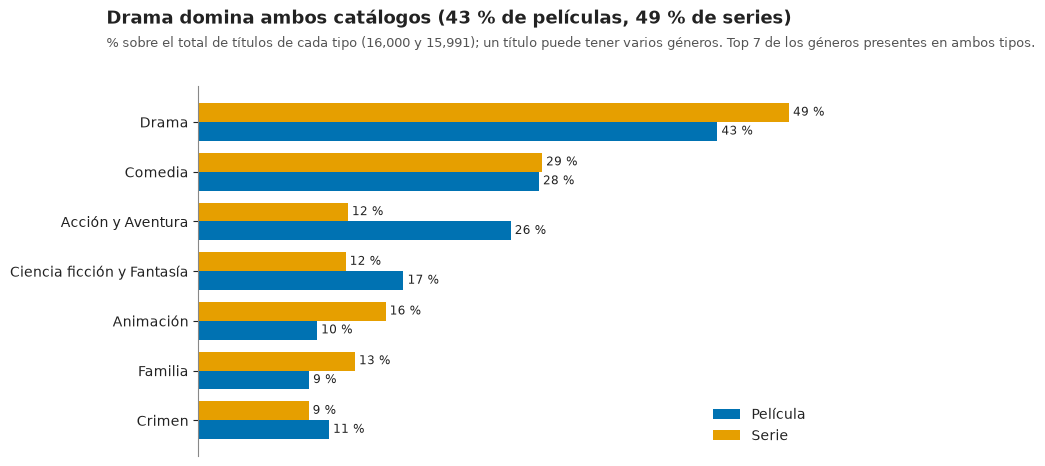

In [5]:
comunes = (set(g[g.tipo_contenido == "Película"].genero_unificado) &
           set(g[g.tipo_contenido == "Serie"].genero_unificado))
v = (g[g.genero_unificado.isin(comunes)].groupby(["genero_unificado", "tipo_contenido"])
       .size().unstack(fill_value=0))
v = v.div(N_TIPO[v.columns], axis=1) * 100            # % sobre base fija = total de títulos del tipo
v = v.loc[v.sum(axis=1).nlargest(7).index].iloc[::-1]
fig, ax = plt.subplots(figsize=(8, 4.8))
h = 0.38; y = np.arange(len(v))
for i, t in enumerate(TIPOS):
    b = ax.barh(y + (i - 0.5) * h, v[t], height=h, color=COLOR[t], label=t)
    ax.bar_label(b, fmt="%.0f %%", padding=3, fontsize=8.5)
ax.set_yticks(y, v.index); ax.set_xticks([]); ax.spines["bottom"].set_visible(False)
ax.legend(frameon=False, loc="lower right")
a_, b_ = v["Película"].idxmax(), v["Serie"].idxmax()
msg = (f"{a_} domina ambos catálogos ({v.loc[a_,'Película']:.0f} % de películas, {v.loc[a_,'Serie']:.0f} % de series)"
       if a_ == b_ else f"{a_} es el género más frecuente en películas y {b_} en series")
encabezado(fig, msg, f"% sobre el total de títulos de cada tipo ({N_TIPO['Película']:,} y {N_TIPO['Serie']:,}); "
                     "un título puede tener varios géneros. Top 7 de los géneros presentes en ambos tipos.")
guardar(fig, "g4_volumen_por_genero.png")
cifra("G4", f"pct_{a_}_Película", v.loc[a_, "Película"]); cifra("G4", f"pct_{a_}_Serie", v.loc[a_, "Serie"])

## G5 — Los títulos de 2025 casi no tienen votos: su nota aún no es fiable
- **Problema:** ¿la calidad percibida cambia con los años, y es confiable para los títulos recientes?
- **Mensaje:** hasta 2024 la cobertura de votos fue alta en películas y creciente en series; el desplome es solo de 2025, por ser títulos recientes.
- **Métrica:** calificación promedio (solo con votos) y % con ≥ 10 votos, por año.
- **Por qué líneas:** tendencia temporal; etiquetas directas al final de cada línea y franja gris en el año reciente. Hay 1.000 títulos por año y tipo, así que el volumen por año no es un hallazgo.

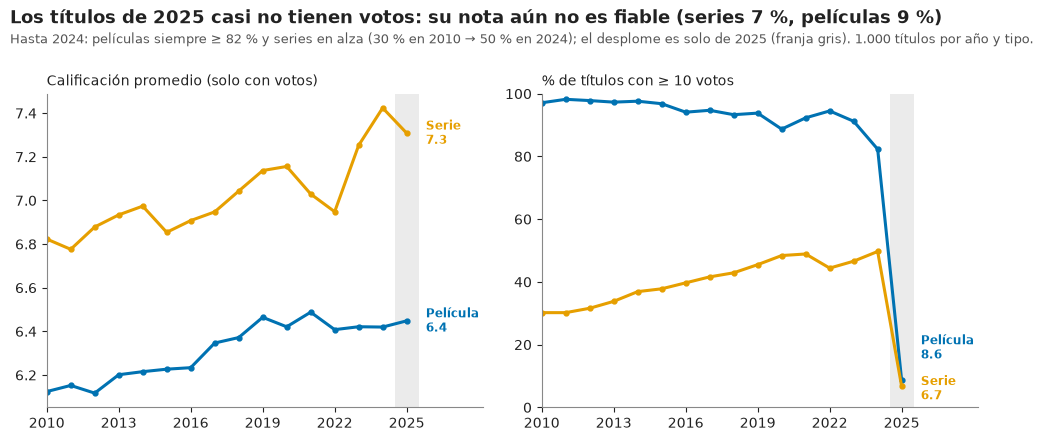

In [6]:
a = (df.groupby(["release_year", "tipo_contenido"])
       .agg(calif=("vote_average_clean", "mean"), conf=("calificacion_confiable", "mean")).reset_index())
a["conf"] *= 100
y1 = int(a.release_year.max())
c1 = a[a.release_year == y1].set_index("tipo_contenido").conf
c0 = a[a.release_year == y1 - 1].set_index("tipo_contenido").conf
y0 = int(a.release_year.min())
s0 = a[(a.release_year == y0) & (a.tipo_contenido == "Serie")].conf.iloc[0]
pmin = a[(a.tipo_contenido == "Película") & (a.release_year < y1)].conf.min()
fig, axes = plt.subplots(1, 2, figsize=(10, 4.2), sharex=True)
for ax_, col, ttl, ylim in [(axes[0], "calif", "Calificación promedio (solo con votos)", None),
                            (axes[1], "conf", "% de títulos con ≥ 10 votos", (0, 100))]:
    ax_.axvspan(y1 - 0.5, y1 + 0.5, color=GRIS, alpha=0.3, linewidth=0)   # año reciente
    for t in TIPOS:
        s = a[a.tipo_contenido == t]
        ax_.plot(s.release_year, s[col], color=COLOR[t], linewidth=2.2, marker="o", markersize=3.5)
        y_et = {"Película": 19, "Serie": 6}[t] if col == "conf" else s[col].iloc[-1]   # evita que las etiquetas se pisen
        ax_.text(y1 + 0.8, y_et, f"{t}\n{s[col].iloc[-1]:.1f}",
                 color=COLOR[t], fontsize=8.5, fontweight="bold", va="center")
    ax_.set_title(ttl, loc="left", fontsize=10)
    if ylim: ax_.set_ylim(*ylim)
    ax_.set_xlim(a.release_year.min(), y1 + 3.2)
    ax_.set_xticks(range(int(a.release_year.min()), y1 + 1, 3))
encabezado(fig, f"Los títulos de {y1} casi no tienen votos: su nota aún no es fiable "
                f"(series {c1['Serie']:.0f} %, películas {c1['Película']:.0f} %)",
           f"Hasta {y1 - 1}: películas siempre ≥ {pmin:.0f} % y series en alza ({s0:.0f} % en {y0} → {c0['Serie']:.0f} % en {y1 - 1}); "
           f"el desplome es solo de {y1} (franja gris). 1.000 títulos por año y tipo.")
fig.tight_layout(); guardar(fig, "g5_evolucion_por_anio.png")
cifra("G5", f"conf_series_{y1 - 1}", c0["Serie"]); cifra("G5", f"conf_series_{y1}", c1["Serie"])
cifra("G5", f"conf_peliculas_{y1}", c1["Película"])

## G6 — Estados Unidos domina las películas, pero no las series
- **Problema:** ¿de dónde viene la oferta de cada tipo?
- **Mensaje:** el país líder concentra casi la mitad de las películas y solo una quinta parte de las series, donde China y Japón pesan casi lo mismo entre sí.
- **Métrica:** % de títulos sobre el total del tipo (base fija), top 7 por tipo, sin «No especificado»; países en español.
- **Por qué barras:** ranking de categorías con nombres largos.

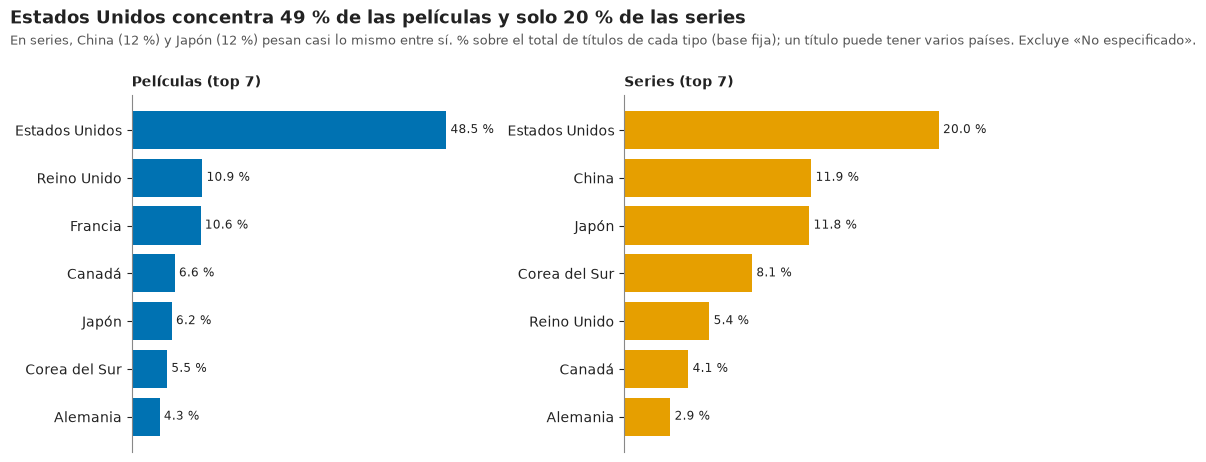

In [7]:
import sys
sys.path.append(str(ROOT / "src"))
from kpis import PAISES_ES                      # traducción única de países (la misma que usa Looker)

p = pais[pais.pais != NO_ESP].assign(pais=lambda x: x.pais.map(PAISES_ES).fillna(x.pais))
fig, axes = plt.subplots(1, 2, figsize=(10, 4.4))
share = {}
for ax_, t in zip(axes, TIPOS):
    s = (p[p.tipo_contenido == t].groupby("pais").size() / N_TIPO[t] * 100)
    share[t] = s
    s7 = s.nlargest(7).sort_values()
    b = ax_.barh(s7.index, s7.values, color=COLOR[t])
    ax_.bar_label(b, fmt="%.1f %%", padding=3, fontsize=8.5)
    ax_.set_xticks([]); ax_.spines["bottom"].set_visible(False)
    ax_.set_title(t + "s (top 7)", loc="left", fontsize=10, fontweight="bold")
    cifra("G6", f"pct_{s7.index[-1]}_{t}", s7.values[-1])
top = share["Película"].idxmax()
otros = share["Serie"].drop(top).nlargest(2)
encabezado(fig, f"{top} concentra {share['Película'][top]:.0f} % de las películas y solo {share['Serie'][top]:.0f} % de las series",
           f"En series, {otros.index[0]} ({otros.iloc[0]:.0f} %) y {otros.index[1]} ({otros.iloc[1]:.0f} %) pesan casi lo mismo entre sí. "
           f"% sobre el total de títulos de cada tipo (base fija); un título puede tener varios países. Excluye «{NO_ESP}».")
fig.tight_layout(); guardar(fig, "g6_paises.png")

## G7 — Relación débil: los títulos más populares tienden a tener algo mejor nota
- **Problema:** ¿los títulos más populares son también los mejor calificados?
- **Mensaje:** la asociación es débil pero existe (r = 0,25 en películas y 0,13 en series); popularidad y calificación no son totalmente independientes.
- **Métrica:** `indice_engagement` (percentil dentro del tipo) vs `vote_average_clean`, solo títulos con ≥ 10 votos.
- **Por qué hexbin:** miles de puntos se superponen en un scatter; la densidad por hexágono (escala log rotulada) evita el amontonamiento.

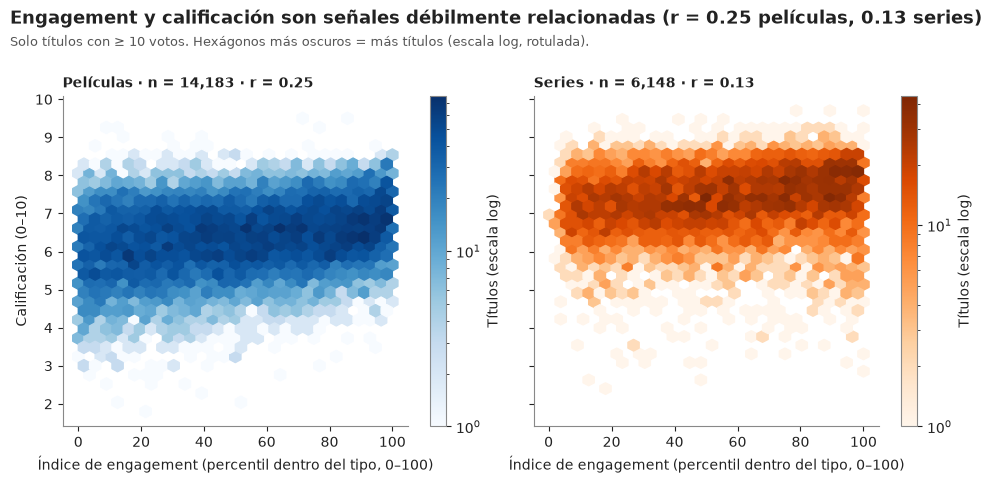

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4.6), sharey=True)
rs = {}
for ax_, t, cm in zip(axes, TIPOS, ["Blues", "Oranges"]):
    s = df[(df.tipo_contenido == t) & df.calificacion_confiable]
    rs[t] = s.indice_engagement.corr(s.vote_average_clean)
    hb = ax_.hexbin(s.indice_engagement, s.vote_average_clean, gridsize=28, mincnt=1, bins="log", cmap=cm)
    plt.colorbar(hb, ax=ax_, label="Títulos (escala log)")
    ax_.set_xlabel("Índice de engagement (percentil dentro del tipo, 0–100)")
    ax_.set_title(f"{t}s · n = {len(s):,} · r = {rs[t]:.2f}", loc="left", fontsize=10, fontweight="bold")
axes[0].set_ylabel("Calificación (0–10)")
rm = max(abs(r) for r in rs.values())
rel = "casi independientes" if rm < 0.1 else "débilmente relacionadas" if rm < 0.4 else "relacionadas"
encabezado(fig, f"Engagement y calificación son señales {rel} (r = {rs['Película']:.2f} películas, {rs['Serie']:.2f} series)",
           "Solo títulos con ≥ 10 votos. Hexágonos más oscuros = más títulos (escala log, rotulada).")
fig.tight_layout(); guardar(fig, "g7_engagement_vs_calidad.png")
for t in TIPOS: cifra("G7", f"r_{t}", rs[t])

## G8 — ROI por director (solo películas): ¿el liderazgo se apoya en una sola película?
- **Problema:** ¿qué directores devuelven más por cada peso invertido, y cuánto depende ese ranking de un único éxito?
- **Mensaje:** el título del gráfico dice si el director líder depende de una sola película (≥ 50 % de sus ingresos) o no.
- **Métrica:** ROI agregado = Σ ingresos ÷ Σ presupuesto, directores con ≥ 5 películas con datos. Orden, largo y título = ROI agregado; la mediana y la dependencia se rotulan como apoyo. Se unifica a la dupla Anthony y Joe Russo para evitar filas duplicadas con idénticas métricas.
- **Por qué barras con línea de 1×:** ranking con referencia de punto de equilibrio. Las series no tienen datos financieros.

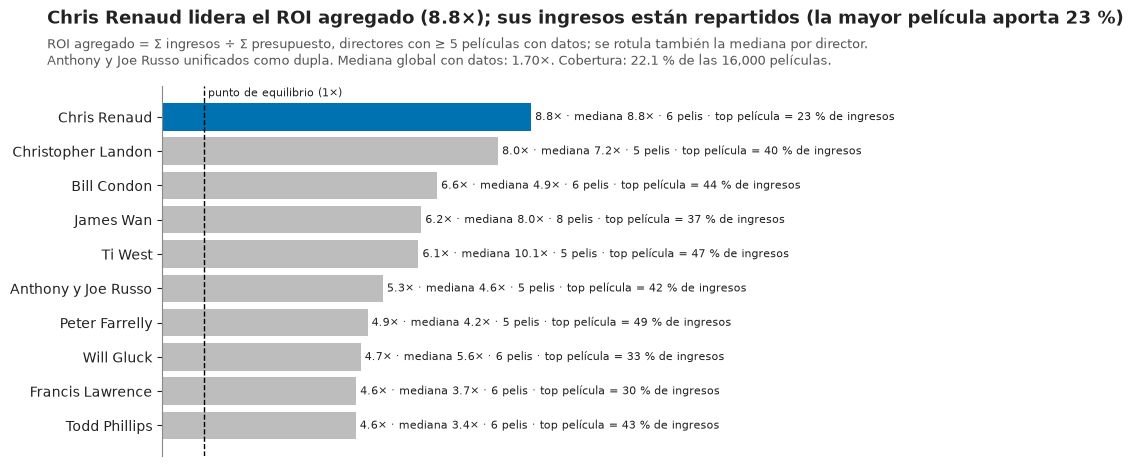

In [9]:
MIN_PELIS = 5                                   # mínimo de películas con datos por director
f = direc[(direc.tipo_contenido == "Película") & direc.tiene_datos_financieros].copy()
# Unificar a Anthony y Joe Russo como dupla para evitar filas duplicadas con idénticas métricas
f["director_ind"] = f["director_ind"].replace({
    "Anthony Russo": "Anthony y Joe Russo",
    "Joe Russo": "Anthony y Joe Russo"
})
f = f.drop_duplicates(subset=["content_id", "director_ind"])

r = (f.groupby("director_ind").agg(n=("content_id", "nunique"), bud=("budget_clean", "sum"),
                                  rev=("revenue_clean", "sum"), mediana=("roi", "median"),
                                  rev_max=("revenue_clean", "max")).reset_index())
r["roi_agregado"] = r.rev / r.bud
r["dep"] = r.rev_max / r.rev * 100              # % de los ingresos que aporta su película más taquillera
r = r[r.n >= MIN_PELIS].nlargest(10, "roi_agregado").sort_values("roi_agregado")
fig, ax = plt.subplots(figsize=(10, 4.8))
ax.barh(r.director_ind, r.roi_agregado,
        color=[COLOR["Película"] if i == len(r) - 1 else GRIS for i in range(len(r))])
for yy, (v_, m_, n_, d_) in enumerate(zip(r.roi_agregado, r.mediana, r.n, r.dep)):
    ax.text(v_, yy, f" {v_:.1f}× · mediana {m_:.1f}× · {n_} pelis · top película = {d_:.0f} % de ingresos",
            va="center", fontsize=8)
ax.axvline(1, color="black", linewidth=1, linestyle="--")
ax.text(1, len(r) - 0.4, " punto de equilibrio (1×)", fontsize=8)
ax.set_xticks([]); ax.spines["bottom"].set_visible(False); ax.set_xlim(0, r.roi_agregado.max() * 2.1)
cob = f.content_id.nunique() / N_TIPO["Película"] * 100
roi_med_global = df.loc[df.tiene_datos_financieros, "roi"].median()    # mismo valor que el KPI (1,70×)
lid = r.iloc[-1]
frase = (f"una sola película aporta {lid.dep:.0f} % de sus ingresos" if lid.dep >= 50
         else f"sus ingresos están repartidos (la mayor película aporta {lid.dep:.0f} %)")
encabezado(fig, f"{lid.director_ind} lidera el ROI agregado ({lid.roi_agregado:.1f}×); {frase}",
           f"ROI agregado = Σ ingresos ÷ Σ presupuesto, directores con ≥ {MIN_PELIS} películas con datos; se rotula también la mediana por director.\n"
           f"Anthony y Joe Russo unificados como dupla. Mediana global con datos: {roi_med_global:.2f}×. Cobertura: {cob:.1f} % de las {N_TIPO['Película']:,} películas.")
guardar(fig, "g8_roi_por_director.png")
cifra("G8", "roi_agregado_top1", lid.roi_agregado); cifra("G8", "cobertura_financiera_pct", cob)
cifra("G8", "roi_mediano_global", roi_med_global); cifra("G8", "dependencia_top1_pct", lid.dep)


In [10]:
# Control: G4 cuenta todos los géneros de cada título; Looker filtra solo por genero_principal.
lk = pd.read_csv(PROC / "looker_contenido.csv")
n_lk = lk.groupby("tipo_contenido").size()
lkp = (lk[lk.genero_principal != NO_ESP].groupby(["genero_principal", "tipo_contenido"]).size()
         .unstack(fill_value=0).div(n_lk, axis=1) * 100)
g4 = (g[g.genero_unificado.isin(comunes)].groupby(["genero_unificado", "tipo_contenido"]).size()
        .unstack(fill_value=0).div(N_TIPO, axis=1) * 100)
cmp_ = (g4.join(lkp, lsuffix="_G4_todos_los_generos", rsuffix="_Looker_genero_principal", how="left").round(1))
cmp_.to_csv(PROC / "control_g4_vs_looker.csv")
display(cmp_.sort_values(cmp_.columns[0], ascending=False).head(7))
print("Diferencia esperada: G4 cuenta cada género de un título; Looker solo el primero. Declararlo en la página de limitaciones.")

tipo_contenido,Película_G4_todos_los_generos,Serie_G4_todos_los_generos,Película_Looker_genero_principal,Serie_Looker_genero_principal
genero_unificado,,,,
Drama,43.2,49.1,22.7,31.5
Comedia,28.3,28.6,14.7,14.5
Acción y Aventura,26.0,12.4,14.2,4.2
Ciencia ficción y Fantasía,17.1,12.2,4.1,2.3
Crimen,10.9,9.2,3.0,4.1
Animación,9.9,15.6,7.0,12.5
Familia,9.2,13.0,2.2,4.0


Diferencia esperada: G4 cuenta cada género de un título; Looker solo el primero. Declararlo en la página de limitaciones.


## Síntesis — Respuesta a la pregunta de negocio
Recomendaciones preliminares para la Gerencia de Contenido; se validan con el dashboard.

In [11]:
from IPython.display import Markdown, display
otros_pais = share["Serie"].drop(top).nlargest(2)
display(Markdown(f"""
**Pregunta:** ¿cómo debería StreamView repartir su inversión en adquisición entre películas y series?

1. **No decidir por la nota promedio de las series (G1, G5).** Puntúan más ({q.loc['Serie','calif']:.2f} vs {q.loc['Película','calif']:.2f}), pero solo {q.loc['Serie','conf']:.0f} % tiene votos suficientes (películas: {q.loc['Película','conf']:.0f} %). Los títulos de {y1} aún no tienen nota fiable.
2. **Medir con la mediana, no con el promedio (G2).** La popularidad está muy sesgada; el promedio sobrestima al título típico.
3. **Cruzar engagement y calidad por género antes de comprar (G3, G7).** Las dos señales se relacionan débilmente (r = {rs['Película']:.2f} en películas y {rs['Serie']:.2f} en series): un género muy visto no garantiza buena nota y viceversa.
4. **La oferta está concentrada (G4, G6).** Drama es el género principal en ambos catálogos y {top} concentra {share['Película'][top]:.0f} % de las películas, frente a {share['Serie'][top]:.0f} % de las series; en series pesan también {otros_pais.index[0]} ({otros_pais.iloc[0]:.0f} %) y {otros_pais.index[1]} ({otros_pais.iloc[1]:.0f} %). Las series ofrecen más diversidad geográfica.
5. **El retorno financiero solo se puede evaluar en películas (G8).** Cobertura: {cob:.0f} % de las películas; ROI mediano de referencia: {roi_med_global:.2f}×. Un ranking de directores puede depender de una sola película: usar la mediana como contraste.

**Límite:** ambas fuentes tienen 1.000 títulos por año y tipo, así que no se infiere el catálogo real.
"""))


**Pregunta:** ¿cómo debería StreamView repartir su inversión en adquisición entre películas y series?

1. **No decidir por la nota promedio de las series (G1, G5).** Puntúan más (7.02 vs 6.31), pero solo 38 % tiene votos suficientes (películas: 89 %). Los títulos de 2025 aún no tienen nota fiable.
2. **Medir con la mediana, no con el promedio (G2).** La popularidad está muy sesgada; el promedio sobrestima al título típico.
3. **Cruzar engagement y calidad por género antes de comprar (G3, G7).** Las dos señales se relacionan débilmente (r = 0.25 en películas y 0.13 en series): un género muy visto no garantiza buena nota y viceversa.
4. **La oferta está concentrada (G4, G6).** Drama es el género principal en ambos catálogos y Estados Unidos concentra 49 % de las películas, frente a 20 % de las series; en series pesan también China (12 %) y Japón (12 %). Las series ofrecen más diversidad geográfica.
5. **El retorno financiero solo se puede evaluar en películas (G8).** Cobertura: 22 % de las películas; ROI mediano de referencia: 1.70×. Un ranking de directores puede depender de una sola película: usar la mediana como contraste.

**Límite:** ambas fuentes tienen 1.000 títulos por año y tipo, así que no se infiere el catálogo real.


In [12]:
pd.DataFrame(CIFRAS).to_csv(PROC / "cifras_clave_eda.csv", index=False)
pd.DataFrame(CIFRAS)

,grafico,cifra,valor
0,G1,calificacion_prom_Película,6.309
1,G1,pct_confiable_Película,88.644
2,G1,calificacion_prom_Serie,7.024
3,G1,pct_confiable_Serie,38.447
4,G2,mediana_popularidad_Película,10.913
5,G2,atipicos_Película,1705.000
6,G2,mediana_popularidad_Serie,36.200
7,G2,atipicos_Serie,1609.000
8,G3,eng_max_Película,66.360
9,G3,calif_max_Película,7.139
